# Processamento de Imagens — Histogramas e Transformações de Intensidade

**Autor:** Gabriel Santos

Este notebook foi feito para rodar no **Google Colab**. Ele:
1. Recebe 3 fotos suas via upload (uma escura demais, uma clara/saturada demais, uma bem exposta);
2. Converte cada uma para tons de cinza e plota o histograma;
3. Pede um diagnóstico de 1–2 frases sobre o histograma (célula de texto para você preencher);
4. Aplica **uma** operação (expansão de contraste, equalização ou correção gamma) escolhida e justificada para cada imagem;
5. Monta a figura antes/depois com os dois histogramas;
6. Termina com a análise comparativa das três imagens.

> Antes de entregar: rode o notebook do início ao fim (`Ambiente de execução > Executar tudo`) para garantir que todas as figuras fiquem visíveis nos outputs, salve (`Ctrl+S` / `Arquivo > Salvar uma cópia no GitHub`) e faça o commit do `.ipynb`.


## 1. Setup e funções reaproveitadas


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

plt.rcParams['figure.figsize'] = (6, 3)


Funções reaproveitadas do notebook da aula (histograma, expansão de contraste, equalização, correção gamma), implementadas com NumPy e as funções prontas do OpenCV pedidas no enunciado.


In [2]:
def histograma(img_gray, titulo="Histograma", ax=None):
    """Calcula e plota o histograma de uma imagem em tons de cinza (0-255)."""
    hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(np.arange(256), hist, width=1.0, color="steelblue")
    ax.set_title(titulo)
    ax.set_xlabel("Intensidade (0-255)")
    ax.set_ylabel("Nº de pixels")
    ax.set_xlim([0, 255])
    return hist, ax


def expandir_contraste(img_gray, L=None, H=None):
    """Expansão de contraste (contrast stretching) linear para a faixa [0, 255].
    L = intensidade mínima considerada, H = intensidade máxima considerada.
    Se L/H não forem informados, usa o mínimo/máximo reais da imagem."""
    if L is None:
        L = int(img_gray.min())
    if H is None:
        H = int(img_gray.max())
    if H <= L:
        return img_gray.copy(), L, H
    img_f = img_gray.astype(np.float32)
    out = (img_f - L) * (255.0 / (H - L))
    out = np.clip(out, 0, 255).astype(np.uint8)
    return out, L, H


def equalizar(img_gray):
    """Equalização de histograma usando a função pronta do OpenCV."""
    return cv2.equalizeHist(img_gray)


def corrigir_gamma(img_gray, gamma=1.0):
    """Correção gamma via LUT (Look-Up Table).
    gamma < 1 clareia a imagem (bom para imagens escuras).
    gamma > 1 escurece a imagem (bom para imagens estouradas/claras)."""
    inv_gamma = 1.0 / gamma
    tabela = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img_gray, tabela)


In [3]:
def figura_antes_depois(gray, out, titulo_antes, titulo_depois, sup_titulo):
    """Monta a figura 2x2: imagem antes/depois (linha 1) e histogramas antes/depois (linha 2)."""
    fig, axs = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle(sup_titulo, fontsize=13)

    axs[0, 0].imshow(gray, cmap="gray", vmin=0, vmax=255)
    axs[0, 0].set_title(titulo_antes)
    axs[0, 0].axis("off")

    axs[0, 1].imshow(out, cmap="gray", vmin=0, vmax=255)
    axs[0, 1].set_title(titulo_depois)
    axs[0, 1].axis("off")

    histograma(gray, f"Histograma - {titulo_antes}", ax=axs[1, 0])
    histograma(out, f"Histograma - {titulo_depois}", ax=axs[1, 1])

    plt.tight_layout()
    plt.show()
    return fig


In [4]:
def carregar_upload(prompt):
    """Abre o widget de upload do Colab e retorna a imagem carregada em BGR (formato OpenCV).
    Se não estiver no Colab, pede o caminho do arquivo local."""
    print(prompt)
    if IN_COLAB:
        uploaded = files.upload()
        nome_arquivo = list(uploaded.keys())[0]
        dados = np.frombuffer(uploaded[nome_arquivo], np.uint8)
        img_bgr = cv2.imdecode(dados, cv2.IMREAD_COLOR)
    else:
        caminho = input("Caminho do arquivo local: ").strip()
        nome_arquivo = caminho
        img_bgr = cv2.imread(caminho, cv2.IMREAD_COLOR)
    assert img_bgr is not None, "Não foi possível carregar a imagem. Tente novamente."
    print(f"Carregado: {nome_arquivo}  |  shape: {img_bgr.shape}")
    return img_bgr, nome_arquivo


Função auxiliar (opcional) para apoiar o diagnóstico: mostra média, desvio padrão e a fração de pixels nas sombras (0–63), meios-tons (64–191) e realces (192–255). **Não substitui a análise escrita — é só um apoio numérico para você confirmar o que está vendo no gráfico.**


In [5]:
def resumo_histograma(img_gray):
    media = img_gray.mean()
    desvio = img_gray.std()
    total = img_gray.size
    sombras = np.sum(img_gray <= 63) / total * 100
    meios = np.sum((img_gray > 63) & (img_gray <= 191)) / total * 100
    realces = np.sum(img_gray > 191) / total * 100
    print(f"Média: {media:.1f}  |  Desvio padrão: {desvio:.1f}")
    print(f"Sombras (0-63): {sombras:.1f}%  |  Meios-tons (64-191): {meios:.1f}%  |  Realces (192-255): {realces:.1f}%")


## 2. Imagem 1 — Foto escura demais

Envie aqui a foto noturna / em contraluz / ambiente interno mal iluminado.


Envie a foto ESCURA DEMAIS:


Saving foto-escura.jpeg to foto-escura.jpeg
Carregado: foto-escura.jpeg  |  shape: (243, 148, 3)


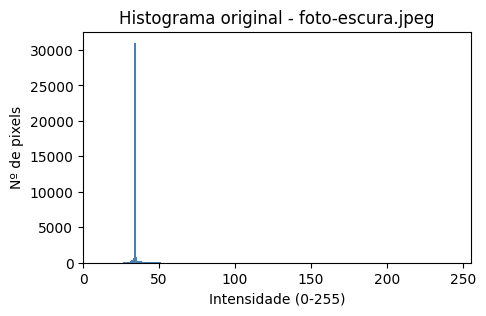

Média: 35.5  |  Desvio padrão: 10.9
Sombras (0-63): 98.4%  |  Meios-tons (64-191): 1.5%  |  Realces (192-255): 0.1%


In [6]:
img1_bgr, nome1 = carregar_upload("Envie a foto ESCURA DEMAIS:")
gray1 = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)

histograma(gray1, f"Histograma original - {nome1}")
plt.show()
resumo_histograma(gray1)


**Diagnóstico (preencha depois de olhar o histograma acima):**

_Em que faixa as intensidades estão concentradas? O que isso indica sobre a imagem?_

> Escreva aqui sua resposta (1–2 frases).


**Operação escolhida:** correção de gamma com `γ < 1` (ex.: `γ = 0.4`), pois ela clareia principalmente os tons mais escuros sem saturar os já claros, ideal para uma imagem cujo histograma está concentrado nas sombras. Ajuste o valor de `gamma` abaixo se necessário e justifique a escolha final no texto.


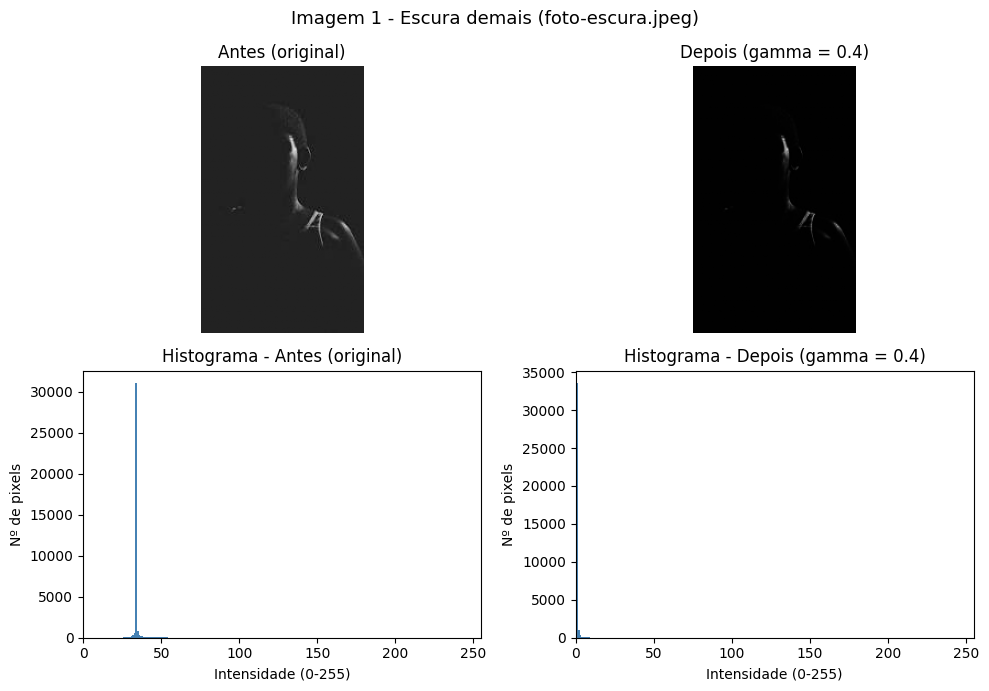

In [7]:
gamma1 = 0.4  # ajuste este parâmetro conforme o resultado visual
out1 = corrigir_gamma(gray1, gamma=gamma1)

fig1 = figura_antes_depois(
    gray1, out1,
    "Antes (original)", f"Depois (gamma = {gamma1})",
    f"Imagem 1 - Escura demais ({nome1})"
)


## 3. Imagem 2 — Foto clara/saturada demais

Envie aqui a foto com flash forte / sol direto / neblina / print de tela clara.


Envie a foto CLARA/SATURADA DEMAIS:


Saving foto-clara.jpeg to foto-clara.jpeg
Carregado: foto-clara.jpeg  |  shape: (415, 740, 3)


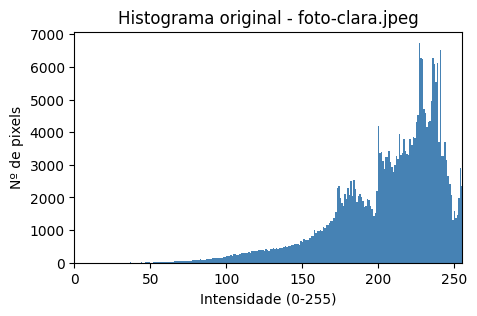

Média: 207.0  |  Desvio padrão: 35.2
Sombras (0-63): 0.1%  |  Meios-tons (64-191): 27.7%  |  Realces (192-255): 72.2%


In [8]:
img2_bgr, nome2 = carregar_upload("Envie a foto CLARA/SATURADA DEMAIS:")
gray2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)

histograma(gray2, f"Histograma original - {nome2}")
plt.show()
resumo_histograma(gray2)


**Diagnóstico (preencha depois de olhar o histograma acima):**

_Em que faixa as intensidades estão concentradas? O que isso indica sobre a imagem?_

> Escreva aqui sua resposta (1–2 frases).


**Operação escolhida:** correção de gamma com `γ > 1` (ex.: `γ = 2.2`), pois ela escurece principalmente os tons mais claros, redistribuindo o histograma que está concentrado nos realces. (Alternativa: expansão de contraste com `L`/`H` ajustados — troque a célula abaixo se preferir essa opção.)


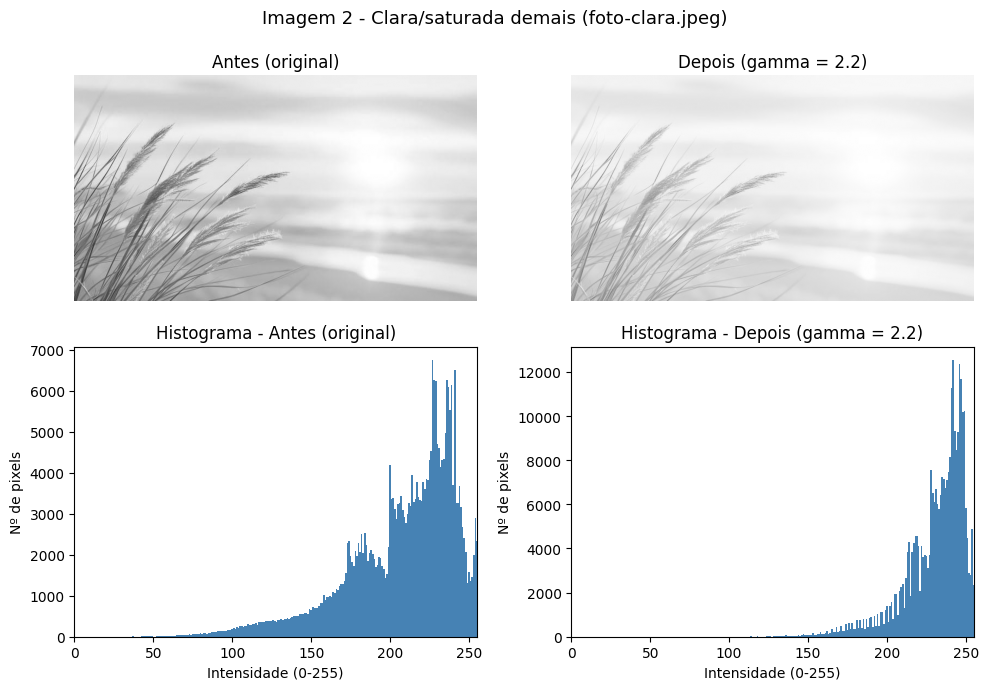

In [9]:
gamma2 = 2.2  # ajuste este parâmetro conforme o resultado visual
out2 = corrigir_gamma(gray2, gamma=gamma2)

fig2 = figura_antes_depois(
    gray2, out2,
    "Antes (original)", f"Depois (gamma = {gamma2})",
    f"Imagem 2 - Clara/saturada demais ({nome2})"
)


## 4. Imagem 3 — Foto bem exposta


Envie a foto BEM EXPOSTA:


Saving foto-exposta.jpeg to foto-exposta.jpeg
Carregado: foto-exposta.jpeg  |  shape: (452, 678, 3)


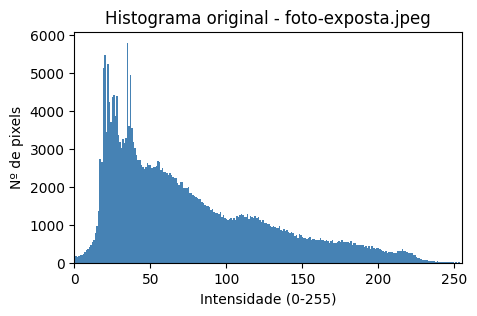

Média: 76.2  |  Desvio padrão: 52.0
Sombras (0-63): 51.7%  |  Meios-tons (64-191): 44.5%  |  Realces (192-255): 3.8%


In [10]:
img3_bgr, nome3 = carregar_upload("Envie a foto BEM EXPOSTA:")
gray3 = cv2.cvtColor(img3_bgr, cv2.COLOR_BGR2GRAY)

histograma(gray3, f"Histograma original - {nome3}")
plt.show()
resumo_histograma(gray3)


**Diagnóstico (preencha depois de olhar o histograma acima):**

_Em que faixa as intensidades estão concentradas? O que isso indica sobre a imagem?_

> Escreva aqui sua resposta (1–2 frases).


**Operação escolhida:** equalização de histograma (`cv2.equalizeHist`), pois é a operação pedida no enunciado para as três imagens e serve aqui de referência: como a imagem já está bem exposta (histograma já ocupa boa parte da faixa 0–255), a equalização tende a produzir uma mudança visualmente pequena — o que ajuda a responder à pergunta final.


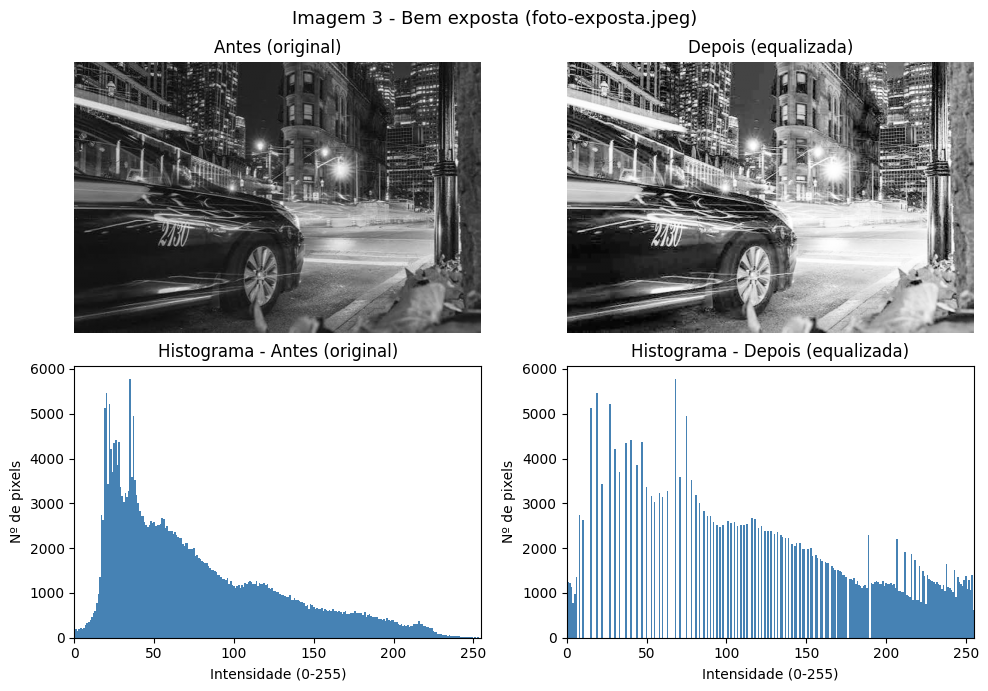

In [11]:
out3 = equalizar(gray3)

fig3 = figura_antes_depois(
    gray3, out3,
    "Antes (original)", "Depois (equalizada)",
    f"Imagem 3 - Bem exposta ({nome3})"
)


## 5. Comparação final

Célula opcional: compara numericamente o quanto cada imagem mudou (diferença média absoluta entre antes e depois), para apoiar a resposta escrita abaixo.


In [12]:
diff1 = np.mean(np.abs(gray1.astype(np.float32) - out1.astype(np.float32)))
diff2 = np.mean(np.abs(gray2.astype(np.float32) - out2.astype(np.float32)))
diff3 = np.mean(np.abs(gray3.astype(np.float32) - out3.astype(np.float32)))

print(f"Diferença média absoluta (antes vs depois):")
print(f"  Imagem 1 (escura):        {diff1:.2f}")
print(f"  Imagem 2 (clara/saturada): {diff2:.2f}")
print(f"  Imagem 3 (bem exposta):    {diff3:.2f}")


Diferença média absoluta (antes vs depois):
  Imagem 1 (escura):        33.86
  Imagem 2 (clara/saturada): 23.42
  Imagem 3 (bem exposta):    53.18
